In [1]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_spline(x_data, y_data, M, x_query):
    
    n = len(x_data)
    h = np.diff(x_data) # step sizes
 
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval

    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = ((M[i] / (6*hi)) * dx_right**3 + (M[i+1] / (6*hi)) * dx_left**3 + (y_data[i] /hi - M[i] *hi/6) * dx_right + (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left)
    
    return S

evaluate spline function

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - ((y[i] - y[i - 1]) / h[i - 1])) # Right-hand side vector
    
    return A, B, C, D

function to setup the tridiagonal matrix, x and y are points getting fit

In [3]:
def thomas_algorithm(a, b, c, d):
    
    a = np.array(a, dtype=float).copy()
    b = np.array(b, dtype=float).copy()
    c = np.array(c, dtype=float).copy()
    d = np.array(d, dtype=float).copy()
    n = len(b)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
        # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
            
    return x

function that evaluates tridiagonal matrix using thomas algorithm

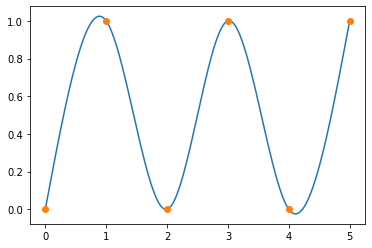

In [4]:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

A, B, C, D = setup_tridiagonal_matrix(x, y)

a = A[1:]
b = B.copy()
c = C[:-1]
d = D.copy()

M2 = thomas_algorithm(a, b, c, d)

M = np.zeros(6)
M[1:-1] = M2

x_CubicFit = np.linspace(x[0], x[-1], 400)
y_CubicFit = evaluate_spline(x, y, M, x_CubicFit)

plt.figure()
plt.plot(x_CubicFit, y_CubicFit)
plt.plot(x, y, "o")
plt.show()


main that runs functions, reformats tridiagonal matrix to be 3,4,3,4, takes middle values from thomas algorithm output (outters are 0), and plots the fit onto the points its fitting.  